<a href="https://colab.research.google.com/github/D2718281828nis/Fuzzy-fundamentals/blob/main/Crisp_vs_Fuzzy_Transfer_Function_Control.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Crisp PD versus fuzzy PD control of a second-order plant

This worked example connects **Automatic Control Theory** with a small, transparent fuzzy controller. The same plant, reference, actuator limit, sample time, and error signals are used for both controllers so that the comparison is meaningful.

We will:

1. derive a classical (crisp) PD controller from a transfer function;
2. build a zero-order Takagi–Sugeno fuzzy PD controller from triangular memberships and a rule table;
3. inspect its memberships and nonlinear control surface;
4. compare time responses and quantitative metrics; and
5. repeat the experiment after changing the plant damping.

Only NumPy, SciPy, Matplotlib, and IPython are required. The fuzzy inference is implemented explicitly (rather than hidden in a fuzzy-control package) so every step can be inspected.

## 1. Plant and classical design

Consider the standard mass–damper plant

\[
G(s)=\frac{Y(s)}{U(s)}=\frac{1}{s(s+1)}.
\]

With zero initial conditions this is equivalent to

\[
\ddot y+\dot y=u.
\]

A crisp PD controller with derivative on the measured output is

\[
u=K_p(r-y)-K_d\dot y.
\]

This common implementation avoids a derivative kick when the reference steps. Unity feedback gives the closed-loop transfer function

\[
\frac{Y(s)}{R(s)}=\frac{K_p}{s^2+(1+K_d)s+K_p}.
\]

Matching the denominator to the textbook second-order polynomial
\(s^2+2\zeta\omega_n s+\omega_n^2\), choose
\(\omega_n=2\) rad/s and \(\zeta=0.75\). Therefore

\[
K_p=\omega_n^2=4,\qquad K_d=2\zeta\omega_n-1=2.
\]

Both simulations include the realistic actuator constraint \(|u|\le4\). This saturation means the implemented loop is nonlinear even for the crisp controller; the transfer-function expression describes the unsaturated nominal design.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import cont2discrete

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(precision=3, suppress=True)

Kp, Kd = 4.0, 2.0
U_MAX = 4.0
DT, T_END = 0.01, 10.0
print(f"Crisp design: Kp={Kp:g}, Kd={Kd:g}, actuator limit=±{U_MAX:g}")

Crisp design: Kp=4, Kd=2, actuator limit=±4


## 2. Fuzzy controller

The fuzzy controller uses the same two signals as PD control:

- normalized error \(E=e/S_e\), with \(S_e=0.50\);
- normalized rate signal \(D=-\dot y/S_d\), equal to \(\dot e/S_d\) away from reference jumps, with \(S_d=1.00\).

Both are clipped to \([-1,1]\). Five linguistic labels cover each input:

| Label | Meaning | Centre |
|---|---|---:|
| NB | negative big | -1.0 |
| NS | negative small | -0.5 |
| ZE | zero | 0.0 |
| PS | positive small | 0.5 |
| PB | positive big | 1.0 |

For each pair of active input memberships, the rule consequent is a singleton. The table below is an interpretable saturated fuzzy-PD rule base: positive error requests positive actuation, while error rate supplies damping. Rows are \(E\), columns are \(D\).

| E \\ D | NB | NS | ZE | PS | PB |
|---|---:|---:|---:|---:|---:|
| **NB** | NB | NB | NB | NS | ZE |
| **NS** | NB | NB | NS | ZE | PS |
| **ZE** | NB | NS | ZE | PS | PB |
| **PS** | NS | ZE | PS | PB | PB |
| **PB** | ZE | PS | PB | PB | PB |

We use product AND and weighted-average defuzzification:

\[
\mu_{ij}=\mu_i(E)\mu_j(D),\qquad
u=\frac{\sum_{ij}\mu_{ij}c_{ij}}{\sum_{ij}\mu_{ij}},\qquad
u_f=S_u\nu,
\]

where \(c_{ij}\in\{-1,-0.5,0,0.5,1\}\) and \(S_u=4\). This zero-order Takagi–Sugeno form is easy to reproduce and has no dependency on a fuzzy library.

In [2]:
LABELS = ("NB", "NS", "ZE", "PS", "PB")
CENTRES = np.linspace(-1.0, 1.0, 5)
SE, SD, SU = 0.50, 1.00, 4.00

# Consequent indices (0=NB, ..., 4=PB), rows E and columns D.
RULE_INDEX = np.array([
    [0, 0, 0, 1, 2],
    [0, 0, 1, 2, 3],
    [0, 1, 2, 3, 4],
    [1, 2, 3, 4, 4],
    [2, 3, 4, 4, 4],
])
RULE_VALUES = CENTRES[RULE_INDEX]

def triangular_memberships(x):
    """Five shoulder/triangle memberships on [-1, 1]; return degrees in label order."""
    x = np.clip(np.asarray(x, dtype=float), -1.0, 1.0)
    width = CENTRES[1] - CENTRES[0]
    mu = np.maximum(1.0 - np.abs(x[..., None] - CENTRES) / width, 0.0)
    # At clipped endpoints the first/last triangle naturally acts as a shoulder.
    return mu

def fuzzy_pd(error, error_rate):
    """Scaled fuzzy inference: fuzzify -> fire rules -> weighted-average defuzzify."""
    E = np.clip(error / SE, -1.0, 1.0)
    D = np.clip(error_rate / SD, -1.0, 1.0)
    mu_e, mu_d = triangular_memberships(E), triangular_memberships(D)
    firing = mu_e[:, None] * mu_d[None, :]  # product AND
    normalized_u = np.sum(firing * RULE_VALUES) / np.sum(firing)
    return SU * normalized_u

# A few checks make sign conventions and bounds explicit.
assert np.isclose(fuzzy_pd(0.0, 0.0), 0.0)
assert fuzzy_pd(0.5, 0.0) > 0 and fuzzy_pd(-0.5, 0.0) < 0
assert abs(fuzzy_pd(10.0, 10.0)) <= SU
print("Fuzzy controller sanity checks passed.")

Fuzzy controller sanity checks passed.


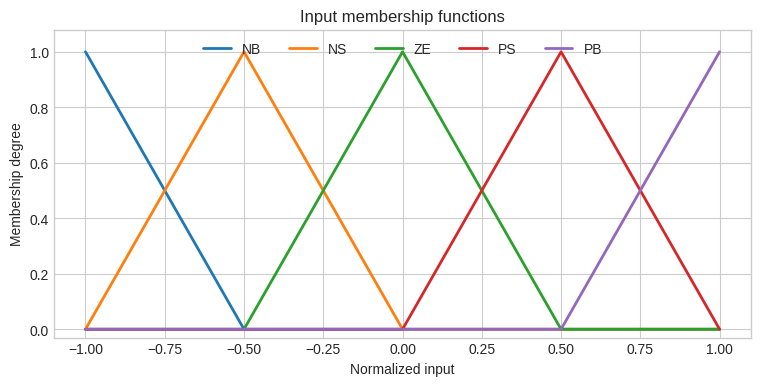

In [3]:
x = np.linspace(-1, 1, 501)
mu = triangular_memberships(x)
fig, ax = plt.subplots(figsize=(9, 4))
for i, label in enumerate(LABELS):
    ax.plot(x, mu[:, i], lw=2, label=label)
ax.set(xlabel="Normalized input", ylabel="Membership degree", title="Input membership functions")
ax.set_ylim(-0.03, 1.08)
ax.legend(ncol=5, loc="upper center")
plt.show()

### Inspect the nonlinear control law

The surface below is the controller itself, not a simulated response. Near the origin it resembles a PD plane. Farther away, linguistic saturation limits the requested action. This gain scheduling/nonlinearity is the main conceptual difference from the constant-gain crisp law \(K_pe-K_d\dot y\).

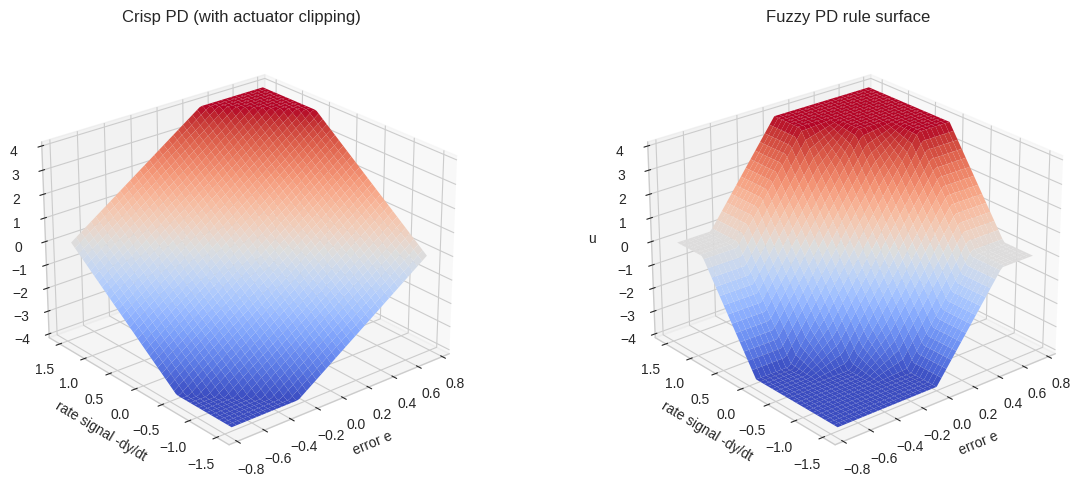

In [4]:
e_grid = np.linspace(-0.75, 0.75, 81)
d_grid = np.linspace(-1.5, 1.5, 81)
EE, DD = np.meshgrid(e_grid, d_grid)
UF = np.vectorize(fuzzy_pd)(EE, DD)
UC = np.clip(Kp * EE + Kd * DD, -U_MAX, U_MAX)

fig = plt.figure(figsize=(13, 5))
ax1 = fig.add_subplot(121, projection="3d")
ax2 = fig.add_subplot(122, projection="3d")
for ax, z, title in [(ax1, UC, "Crisp PD (with actuator clipping)"),
                     (ax2, UF, "Fuzzy PD rule surface")]:
    ax.plot_surface(EE, DD, z, cmap="coolwarm", vmin=-U_MAX, vmax=U_MAX,
                    linewidth=0, antialiased=True)
    ax.set(xlabel="error e", ylabel="rate signal -dy/dt", zlabel="u", title=title)
    ax.view_init(elev=25, azim=-130)
fig.tight_layout()
plt.show()

## 3. Fair closed-loop simulation

Use the controllable state-space realization

\[
\dot x=\begin{bmatrix}0&1\\0&-a\end{bmatrix}x+
\begin{bmatrix}0\\1\end{bmatrix}u,\qquad y=\begin{bmatrix}1&0\end{bmatrix}x,
\]

where \(a=1\) is the nominal damping. SciPy converts it exactly to a zero-order-hold discrete model at 10 ms. At every sample, either controller sees the same exact states: \(e=r-y\), and for a constant set point \(\dot e=-\dot y\). No numerical differentiation or measurement noise is introduced.

The reference changes from 0 to 1 at 0.5 s. A load disturbance of -0.8 is added at the plant input from 5 to 6 s. It is **not** shown to either controller. This tests transient tracking and disturbance recovery in one run.

In [9]:
def reference(t):
    return 0.0 if t < 0.5 else 1.0

def load_disturbance(t):
    return -1.8 if 5.0 <= t < 6.0 else 0.0

def simulate(controller, damping=1.0):
    A = np.array([[0.0, 1.0], [0.0, -damping]])
    B = np.array([[0.0], [1.0]])
    C, Dmat = np.array([[1.0, 0.0]]), np.zeros((1, 1))
    Ad, Bd, _, _, _ = cont2discrete((A, B, C, Dmat), DT, method="zoh")
    t = np.arange(0.0, T_END + DT, DT)
    state = np.zeros(2)
    y = np.zeros_like(t); u = np.zeros_like(t); e = np.zeros_like(t)
    for k, tk in enumerate(t):
        y[k] = state[0]
        e[k] = reference(tk) - y[k]
        error_rate = -state[1]  # derivative of a constant reference minus y_dot
        raw_u = controller(e[k], error_rate)
        u[k] = np.clip(raw_u, -U_MAX, U_MAX)
        if k < len(t) - 1:
            total_input = u[k] + load_disturbance(tk)
            state = Ad @ state + Bd[:, 0] * total_input
    return {"t": t, "y": y, "u": u, "e": e}

crisp_controller = lambda e, de: Kp * e + Kd * de
nominal = {
    "Crisp PD": simulate(crisp_controller),
    "Fuzzy PD": simulate(fuzzy_pd),
}

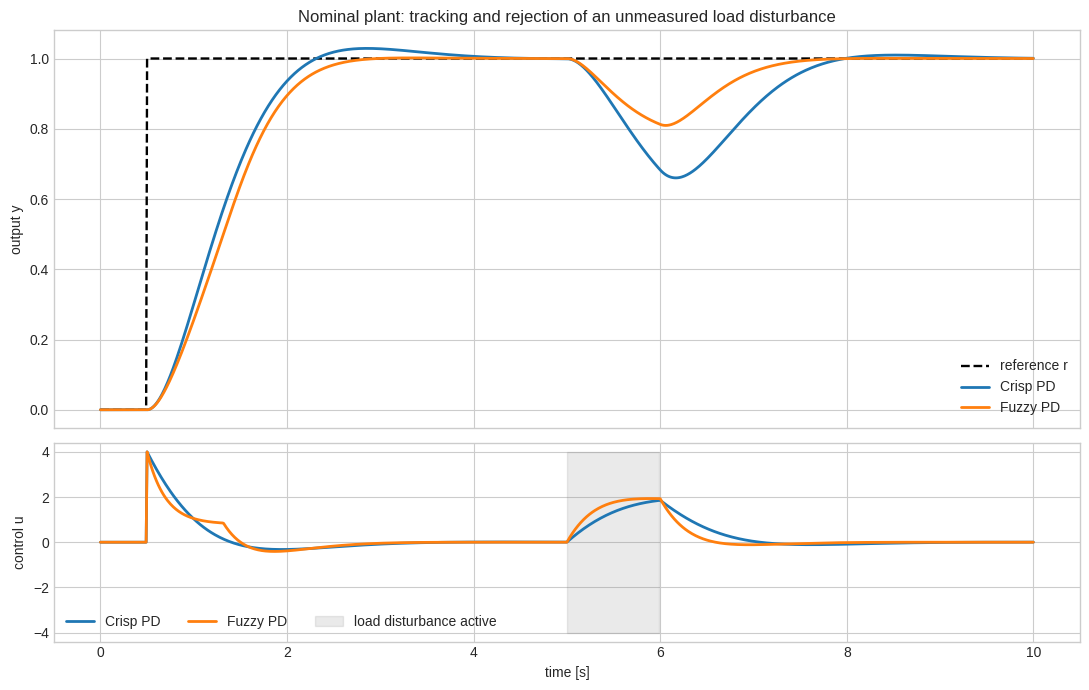

In [10]:
def plot_comparison(results, title):
    t = next(iter(results.values()))["t"]
    r = np.array([reference(tk) for tk in t])
    d = np.array([load_disturbance(tk) for tk in t])
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True,
                                   gridspec_kw={"height_ratios": [2, 1]})
    ax1.plot(t, r, "k--", lw=1.7, label="reference r")
    for name, result in results.items():
        ax1.plot(t, result["y"], lw=2, label=name)
        ax2.plot(t, result["u"], lw=2, label=name)
    ax2.fill_between(t, -U_MAX, U_MAX, where=d != 0, color="grey", alpha=0.16,
                     label="load disturbance active")
    ax1.set(ylabel="output y", title=title)
    ax2.set(xlabel="time [s]", ylabel="control u", ylim=(-4.4, 4.4))
    ax1.legend(); ax2.legend(ncol=3)
    fig.tight_layout()
    plt.show()

plot_comparison(nominal, "Nominal plant: tracking and rejection of an unmeasured load disturbance")

## 4. Quantitative comparison

Visual inspection should be supported by metrics. They are calculated after the step starts (\(t\ge0.5\) s):

- **overshoot**: peak amount above the unit target, as a percentage;
- **2% settling time**: the first time after which the response remains within \(1\pm0.02\) until the disturbance begins (only the pre-disturbance interval is used);
- **IAE**: integral of absolute error over the complete post-step experiment;
- **control energy**: \(\int u^2dt\), a simple effort indicator.

No single metric makes a controller universally “better”; the table exposes the trade-offs.

/tmp/ipykernel_1722/2984242471.py:13: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  "IAE": np.trapz(np.abs(e[after_step]), t[after_step]),
/tmp/ipykernel_1722/2984242471.py:14: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  "control energy": np.trapz(u[after_step] ** 2, t[after_step]),


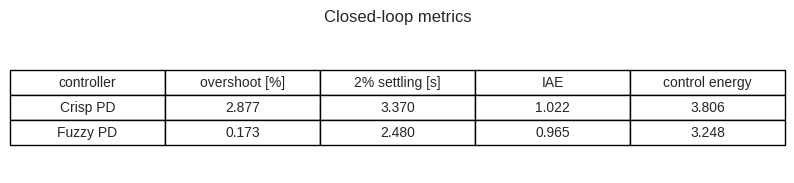

In [7]:
def metrics(result):
    t, y, u, e = (result[key] for key in ("t", "y", "u", "e"))
    after_step = t >= 0.5
    before_disturbance = (t >= 0.5) & (t < 5.0)
    ts, ys = t[before_disturbance], y[before_disturbance]
    outside = np.flatnonzero(np.abs(ys - 1.0) > 0.02)
    settling = np.nan if len(outside) and outside[-1] == len(ys)-1 else (
        ts[0] if len(outside) == 0 else ts[outside[-1] + 1]
    )
    return {
        "overshoot [%]": 100 * max(0.0, np.max(ys) - 1.0),
        "2% settling [s]": settling,
        "IAE": np.trapz(np.abs(e[after_step]), t[after_step]),
        "control energy": np.trapz(u[after_step] ** 2, t[after_step]),
    }

metric_names = list(metrics(next(iter(nominal.values()))))
values = [[name] + [metrics(result)[m] for m in metric_names]
          for name, result in nominal.items()]
fig, ax = plt.subplots(figsize=(10, 1.7))
ax.axis("off")
table = ax.table(cellText=[[row[0]] + [f"{v:.3f}" for v in row[1:]] for row in values],
                 colLabels=["controller"] + metric_names, cellLoc="center", loc="center")
table.auto_set_font_size(False); table.set_fontsize(10); table.scale(1, 1.5)
ax.set_title("Closed-loop metrics", pad=15)
plt.show()

## 5. Robustness illustration: the model changes

A transfer-function design depends on a model. To make that point visible, repeat the experiment after reducing the damping coefficient from \(a=1\) to \(a=0.35\):

\[
G_{changed}(s)=\frac{1}{s(s+0.35)}.
\]

Neither controller is retuned. This is an illustration, not a proof of robust stability: a real design must test the full uncertainty set and account for sampling, delays, noise, and actuator dynamics.

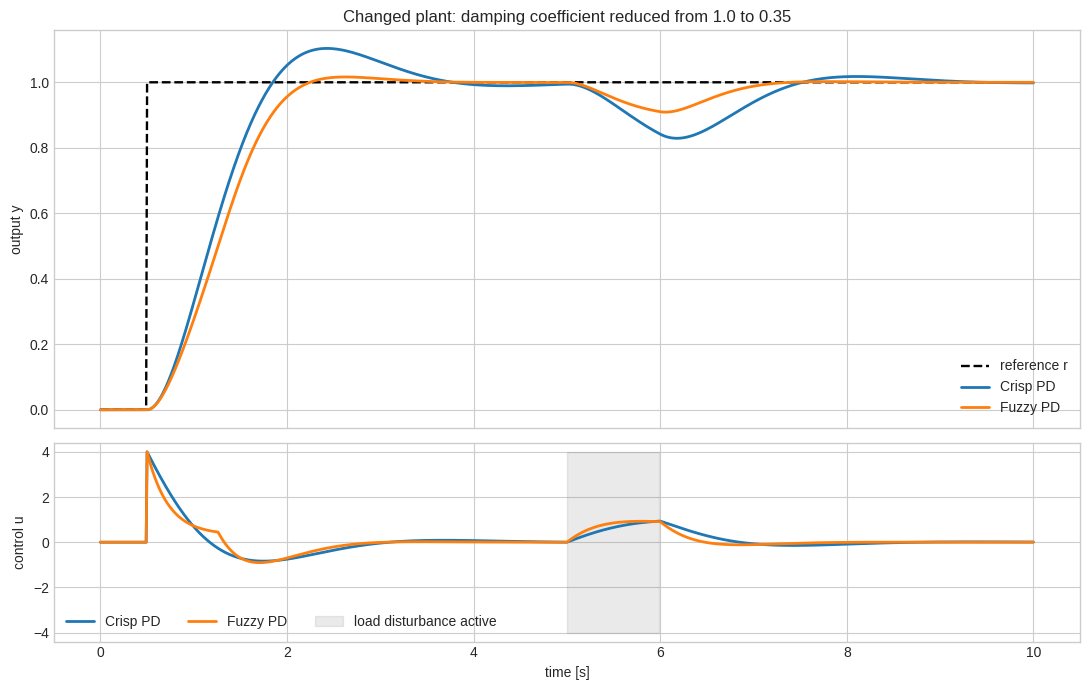

In [8]:
changed = {
    "Crisp PD": simulate(crisp_controller, damping=0.35),
    "Fuzzy PD": simulate(fuzzy_pd, damping=0.35),
}
plot_comparison(changed, "Changed plant: damping coefficient reduced from 1.0 to 0.35")

## 6. What the comparison demonstrates

- **Crisp PD is analytic and compact.** Pole placement gives an immediate relationship among \(K_p\), \(K_d\), damping ratio, and natural frequency for the unsaturated nominal model.
- **Fuzzy PD is a nonlinear mapping.** It encodes qualitative actions (“if error is PB and error-rate is NS, output is PB”) and smoothly blends neighboring rules.
- **Scaling factors are gains.** \(S_e\), \(S_d\), and \(S_u\) are not cosmetic; together with the rule table they determine local sensitivity, saturation, and performance.
- **The comparison is fair but not an optimization contest.** Both controllers use the same information and limits, while the displayed parameters were chosen for explanation rather than exhaustively tuned to win a metric.
- **Neither PD controller rejects a constant input disturbance perfectly while it remains active.** Integral action would be the standard crisp remedy; a fuzzy PI/PID structure could likewise add accumulated error.
- **Fuzzy control does not remove control-theory obligations.** Stability analysis, anti-windup (when integral action exists), noise filtering, delay margins, and validation over the operating envelope still matter.

### Experiments to try

1. Change `SE`, `SD`, or `SU` one at a time and replot the control surface and responses.
2. Modify a single rule, then identify where its effect appears on the surface.
3. Increase `DT` to see how sampling changes both loops.
4. Add sensor noise and replace the exact error-rate signal with a filtered derivative.
5. Extend both designs with integral action and compare rejection of a persistent load.